In [4]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate = 1000
duration = 2.0

N = int(sample_rate * duration)

time = np.arange(N)/sample_rate

signal = np.zeros(N)

#first half with freq 100Hz , second half with freq 300 Hz
signal[:1000] = np.sin(2 * np.pi * 100 * time[:1000])
signal[1000:] = np.sin(2 * np.pi * 300 * time[1000:])  


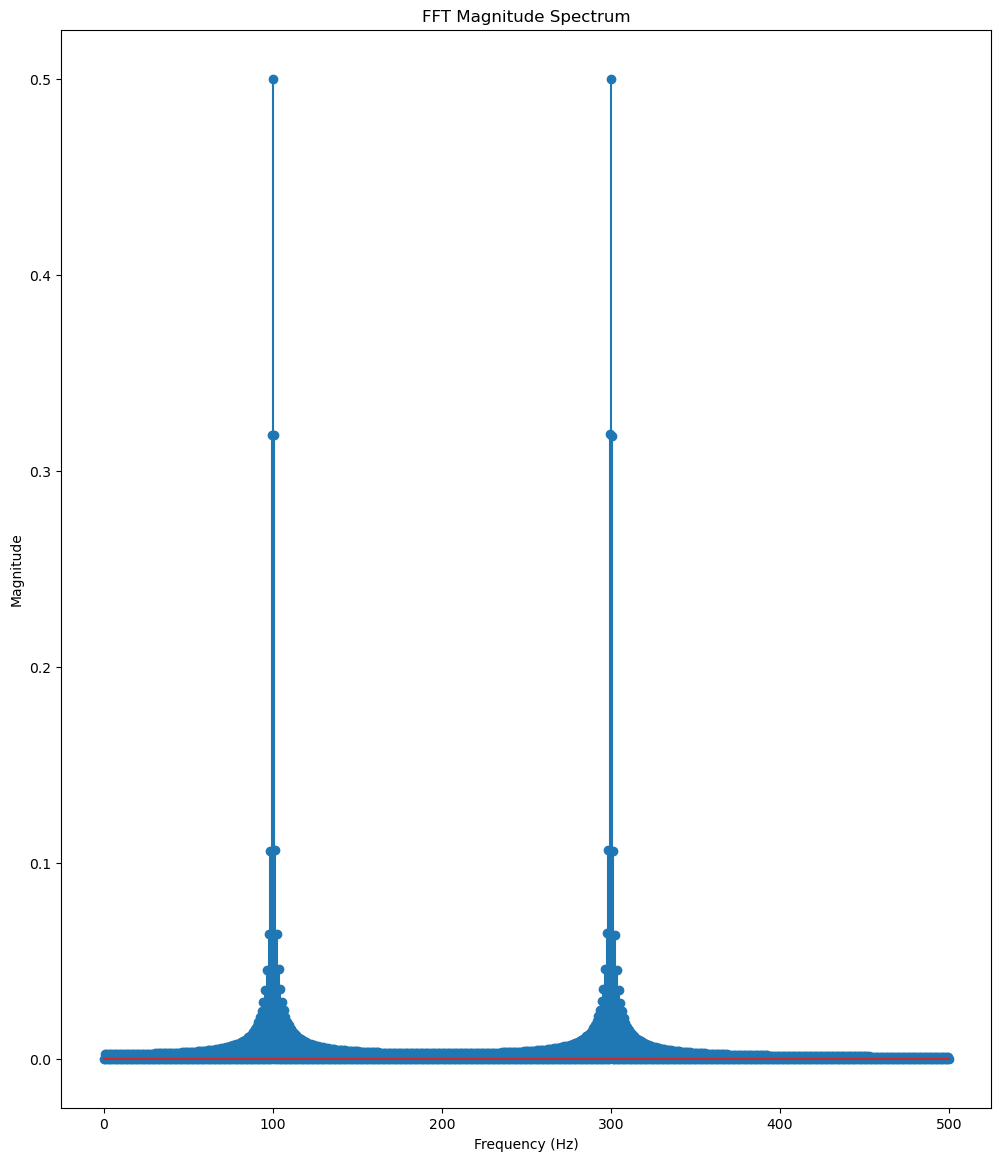

In [9]:
#using fft it doesnt tell us anything about when those frequencies occur and for how long
spectrum = np.fft.rfft(signal)

frequencies = np.fft.rfftfreq(
    N,
    d=1/sample_rate
)

magnitude = np.abs(spectrum) / N

magnitude[1:-1] *= 2

plt.figure(figsize=(12,14))
plt.stem(frequencies,magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Magnitude Spectrum")
plt.show()

In [15]:
#writing manual stft code
frame_length = 256
hop_length = 128

window = np.hanning(frame_length)
#we start processing each overlapping frame within a duration of 2sec
frames = [] #stores the amplitude

for start in range(0,len(signal)-frame_length+1,hop_length):
    frame = signal[start:start+frame_length]

    windowed_frame = frame * window

    windowed_fft = np.fft.rfft(windowed_frame)

    frames.append(np.abs(windowed_fft)) #[[magx1,magx2,magx3..],[magy1,magy2,magy3..]....]

# shape:
# frames_magnitude × frequency_bins is the array structure
stft = np.array(frames)
print(stft.shape) #(14, 129) 14 rows for each frame and each indi frame has 129(256/2 +1 ) values in their spectrum for magnitude 
#as frame_length = 256 and doing fft gives half of the values cancelling out negative freq
"""
frequencies[0]   # 0 Hz
frequencies[1]   # 3.90625 Hz
frequencies[2]   # 7.8125 Hz
...
frequencies[128] # 500 Hz per frame appended is what frequencies look like.
"""
# transpose: done for visualization purpose we want 
# frequency_bins × frames
stft = stft.T #129*14

#frequencies
frequencies = np.fft.rfftfreq(frame_length,d = 1/sample_rate)
frame_times = (np.arange(stft.shape[1]) * hop_length/sample_rate)



(14, 129)


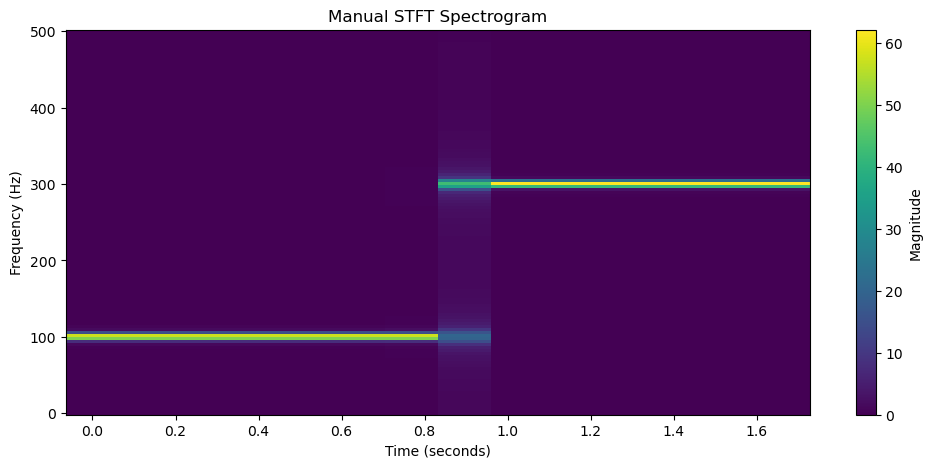

In [14]:
plt.figure(figsize=(12, 5))

plt.pcolormesh(
    frame_times,
    frequencies,
    stft,
    shading="auto"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("Manual STFT Spectrogram")

plt.colorbar(label="Magnitude")

plt.show()

In [ ]:
#the overlap is clearly because of hop length smaller than the frame length if we make frame_length = hop_length we can get that separated version 
"""
clear understanding of the time axis
we have hop_l = 128
sample_rate = 1000
hence we sampling per second we take 1000 samples frames are in a overlapping way calculated meaning each new frame starts at 128/1000 which is 
at 128ms in total for 
2000%256 = 208
2000-208 = 1792 is actual signal length 
1792/128 = 14 exactly

hence from 0 -256 has exactly an overlapping junction of 128ms 

"""


"""reason why 0Hz is not at the top and 500Hz at the bottom
Your STFT matrix itself has rows ordered like:
row 0   -> 0 Hz
row 1   -> 3.906 Hz
...
row 128 -> 500 Hz
But when you plot with:
plt.pcolormesh(
    frame_times,
    frequencies,
    stft,
    shading="auto"
)
Matplotlib uses the frequencies values as y-coordinates, so:0
appears at the bottom and:
500 Hz
at the top.
So the matrix row order is:
top of array in memory/display:
row 0 -> 0 Hz
row 1 -> 3.9 Hz
...
row 128 -> 500 Hz
but the plotted coordinate system places larger y-values higher, giving:
plot:
500 Hz  top
...
0 Hz    bottom
"""

In [17]:
from scipy.signal import stft

frequencies, times, Zxx = stft(
    signal,
    fs=sample_rate,
    nperseg=256,
    noverlap=128
)

magnitude = np.abs(Zxx)

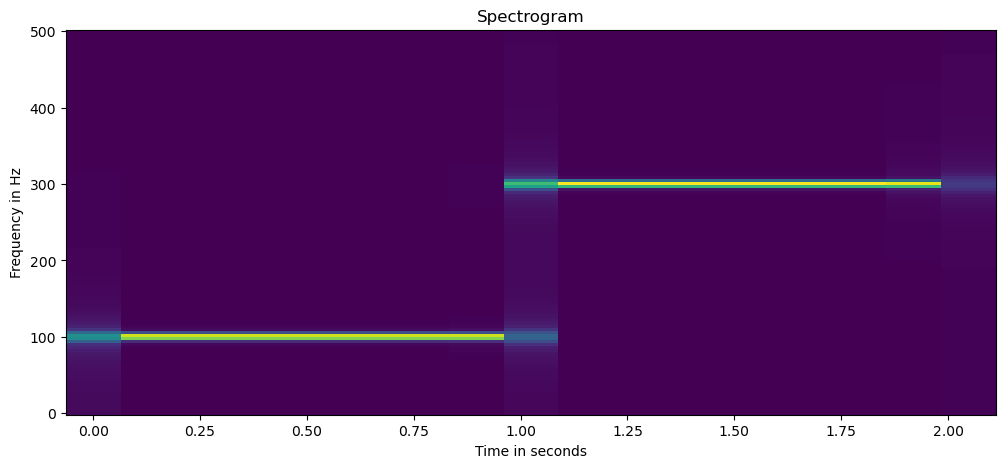

In [18]:
plt.figure(figsize=(12, 5))

plt.pcolormesh(
    times,
    frequencies,
    magnitude,
    shading="auto"
)

plt.xlabel("Time in seconds")
plt.ylabel("Frequency in Hz")
plt.title("Spectrogram")

plt.show()

In [28]:
#The beginners full circle moment , librosa STFT
import librosa

stft_result = librosa.stft(
    signal,
    n_fft = 256,
    hop_length = 128,
    win_length = 256,
    window = "hann"
)

magnitude = np.abs(stft_result)

magnitude_db = librosa.amplitude_to_db(
    magnitude,
    ref=np.max
)

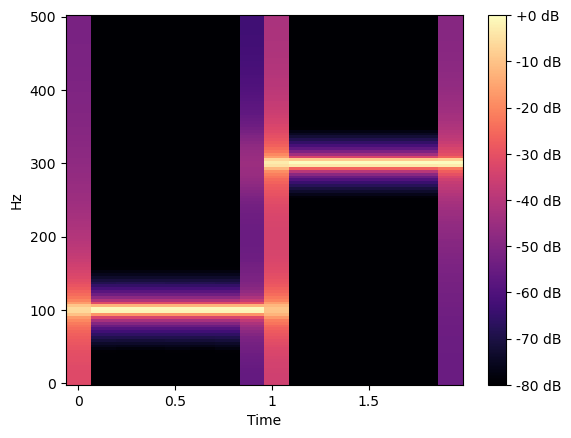

In [30]:
import librosa.display
import matplotlib.pyplot as plt

librosa.display.specshow(
    magnitude_db,
    sr=sample_rate,
    hop_length=128,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.show()